# GWAnalytics: Gravitational Wave Parameter Estimation with JAX-NUTS

This notebook demonstrates the full pipeline:
1. **GWOSC Catalog Exploration** -- Query the GWTC database
2. **Data Extraction** -- Download and whiten LIGO strain data
3. **NUTS Parameter Estimation** -- Run JAX-compiled PyMC NUTS with IMRPhenomD
4. **Posterior Analysis** -- Corner plots, convergence diagnostics, BIC/AIC

In [16]:
import sys, os
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import numpy as np
import arviz as az
import corner
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps
from gw_analytics import GWCatalogAnalyzer, GWNUTSSampler

az.rcParams["plot.backend"] = "matplotlib"

# gwpy patches matplotlib Axes to its own subclass (gwpy.plot.axes.Axes)
# arviz_plots.backend_from_object inspects obj.__module__ and sees "gwpy"
# instead of "matplotlib", causing ModuleNotFoundError. Remap it here.
import arviz_plots.plot_collection as _pc
import arviz_plots.visuals as _visuals
_orig_bfo = _pc.backend_from_object
def _bfo_patch(obj, return_module=True):
    b = _orig_bfo(obj, return_module=False)
    if b == "gwpy":
        b = "matplotlib"
    if return_module:
        return __import__(f"arviz_plots.backend.{b}", fromlist=[""])
    return b
_pc.backend_from_object = _bfo_patch
_visuals.backend_from_object = _bfo_patch

%matplotlib inline

## 1. GWOSC Catalog Exploration
Query the full GWTC catalog for available events and parameter correlations.

In [17]:
research_engine = GWCatalogAnalyzer(catalog_name="GWTC")
df_properties = research_engine.extract_all_properties()

print("\nAvailable Parameter Dimensions:")
print(list(df_properties.columns))

summary_stats = research_engine.generate_statistical_profile()
display(summary_stats.head(10))

corr = research_engine.calculate_astrophysical_correlations()
display(corr.style.background_gradient(cmap='coolwarm', axis=None))

outliers = research_engine.isolate_outliers(column_name='chi_eff', top_n=5)
display(outliers)

Connecting to GWOSC API... Extracting full 'GWTC' parameter space.
Success: Extracted 42 unique properties across 391 documented events.

Available Parameter Dimensions:
['commonName', 'version', 'catalog.shortName', 'GPS', 'reference', 'jsonurl', 'mass_1_source', 'mass_1_source_lower', 'mass_1_source_upper', 'mass_2_source', 'mass_2_source_lower', 'mass_2_source_upper', 'network_matched_filter_snr', 'network_matched_filter_snr_lower', 'network_matched_filter_snr_upper', 'luminosity_distance', 'luminosity_distance_lower', 'luminosity_distance_upper', 'chi_eff', 'chi_eff_lower', 'chi_eff_upper', 'total_mass_source', 'total_mass_source_lower', 'total_mass_source_upper', 'chirp_mass_source', 'chirp_mass_source_lower', 'chirp_mass_source_upper', 'chirp_mass', 'chirp_mass_lower', 'chirp_mass_upper', 'redshift', 'redshift_lower', 'redshift_upper', 'far', 'far_lower', 'far_upper', 'p_astro', 'p_astro_lower', 'p_astro_upper', 'final_mass_source', 'final_mass_source_lower', 'final_mass_source_u

,count,mean,std,min,25%,50%,75%,max
version,391.0,1.514066e+00,6.194966e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
GPS,391.0,1.359938e+09,6.707630e+07,1.126259e+09,1.370015e+09,1.383892e+09,1.404131e+09,1.421382e+09
mass_1_source,282.0,3.539862e+01,1.992684e+01,1.460000e+00,1.980000e+01,3.495000e+01,4.500000e+01,1.370000e+02
mass_1_source_lower,282.0,-7.791950e+00,5.923168e+00,-3.300000e+01,-1.100000e+01,-6.300000e+00,-3.300000e+00,-1.000000e-01
mass_1_source_upper,282.0,1.285560e+01,1.556612e+01,1.200000e-01,5.600000e+00,9.200000e+00,1.500000e+01,1.660000e+02
mass_2_source,282.0,2.285284e+01,1.338476e+01,1.170000e+00,1.010000e+01,2.400000e+01,3.055000e+01,1.010000e+02
mass_2_source_lower,282.0,-7.299965e+00,6.054773e+00,-5.000000e+01,-1.000000e+01,-6.200000e+00,-2.600000e+00,-6.000000e-02
mass_2_source_upper,282.0,7.479291e+00,6.135001e+00,7.000000e-02,2.500000e+00,6.300000e+00,1.070000e+01,3.600000e+01
network_matched_filter_snr,391.0,1.176113e+01,5.961382e+00,4.500000e+00,8.750000e+00,1.020000e+01,1.250000e+01,7.860000e+01
network_matched_filter_snr_lower,89.0,-5.303371e-01,4.222248e-01,-3.000000e+00,-6.000000e-01,-4.000000e-01,-3.000000e-01,-2.000000e-01


,mass_1_source,mass_1_source_lower,mass_1_source_upper,mass_2_source,mass_2_source_lower,mass_2_source_upper,network_matched_filter_snr,network_matched_filter_snr_lower,network_matched_filter_snr_upper,luminosity_distance,luminosity_distance_lower,luminosity_distance_upper,total_mass_source,total_mass_source_lower,total_mass_source_upper,chirp_mass_source,chirp_mass_source_lower,chirp_mass_source_upper,chirp_mass,chirp_mass_lower,chirp_mass_upper,final_mass_source,final_mass_source_lower,final_mass_source_upper
mass_1_source,1.000000,-0.849848,0.486172,0.914629,-0.920185,0.887344,-0.072419,-0.150519,0.186667,0.670624,-0.660993,0.589814,0.987216,-0.865299,0.568749,0.966448,-0.913706,0.785515,nan,nan,nan,0.988052,-0.859738,0.541566
mass_1_source_lower,-0.849848,1.000000,-0.746879,-0.627956,0.766880,-0.938421,0.317845,0.567356,-0.596082,-0.763301,0.776444,-0.814687,-0.782365,0.927202,-0.791735,-0.730653,0.850474,-0.892762,nan,nan,nan,-0.783667,0.937018,-0.776933
mass_1_source_upper,0.486172,-0.746879,1.000000,0.300299,-0.455671,0.716750,-0.277555,-0.861105,0.920263,0.531925,-0.575878,0.825792,0.431034,-0.735962,0.980226,0.381740,-0.587623,0.833158,nan,nan,nan,0.429475,-0.747573,0.984837
mass_2_source,0.914629,-0.627956,0.300299,1.000000,-0.908445,0.745485,0.032399,0.118259,-0.070395,0.594881,-0.577208,0.439938,0.966259,-0.738103,0.404671,0.986648,-0.845780,0.654118,nan,nan,nan,0.963844,-0.719134,0.370713
mass_2_source_lower,-0.920185,0.766880,-0.455671,-0.908445,1.000000,-0.862401,0.170384,0.069377,-0.109128,-0.668456,0.674349,-0.575097,-0.934496,0.859481,-0.539978,-0.933741,0.959104,-0.770620,nan,nan,nan,-0.933012,0.845676,-0.511054
mass_2_source_upper,0.887344,-0.938421,0.716750,0.745485,-0.862401,1.000000,-0.282387,-0.537636,0.557752,0.808860,-0.826283,0.839823,0.853772,-0.938285,0.790053,0.819988,-0.917704,0.961906,nan,nan,nan,0.854155,-0.942107,0.770854
network_matched_filter_snr,-0.072419,0.317845,-0.277555,0.032399,0.170384,-0.282387,1.000000,0.554170,-0.451390,-0.402612,0.412377,-0.398358,-0.016312,0.293291,-0.282945,-0.014190,0.225986,-0.292783,nan,nan,nan,-0.037192,0.301446,-0.282527
network_matched_filter_snr_lower,-0.150519,0.567356,-0.861105,0.118259,0.069377,-0.537636,0.554170,1.000000,-0.952195,-0.454821,0.530366,-0.866501,-0.061953,0.593619,-0.851201,0.021777,0.338201,-0.712590,nan,nan,nan,-0.059789,0.614380,-0.859665
network_matched_filter_snr_upper,0.186667,-0.596082,0.920263,-0.070395,-0.109128,0.557752,-0.451390,-0.952195,1.000000,0.423234,-0.504488,0.869113,0.103622,-0.618201,0.909491,0.023320,-0.369615,0.742062,nan,nan,nan,0.109511,-0.642471,0.919303
luminosity_distance,0.670624,-0.763301,0.531925,0.594881,-0.668456,0.808860,-0.402612,-0.454821,0.423234,1.000000,-0.989211,0.851998,0.654778,-0.786207,0.624280,0.637982,-0.731327,0.800553,nan,nan,nan,0.651138,-0.786531,0.602839


,commonName,version,catalog.shortName,GPS,reference,jsonurl,mass_1_source,mass_1_source_lower,mass_1_source_upper,mass_2_source,...,redshift_upper,far,far_lower,far_upper,p_astro,p_astro_lower,p_astro_upper,final_mass_source,final_mass_source_lower,final_mass_source_upper
name,,,,,,,,,,,,,,,,,,,,,
GW190403_051519-v1,GW190403_051519,1,GWTC-2.1-confident,1.238304e+09,/GWTC-2.1/,https://gwosc.org/eventapi/json/GWTC-2.1-confi...,85.0,-33.0,27.8,20.00,...,0.73,7.70000,NaN,NaN,0.60924,NaN,NaN,102.2,-24.3,26.3
GW241011_233834-v2,GW241011_233834,2,GWTC-5.0,1.412725e+09,/GWTC-5.0/,https://gwosc.org/eventapi/json/GWTC-5.0/GW241...,19.5,-2.0,2.6,5.96,...,0.01,0.00001,NaN,NaN,0.99000,NaN,NaN,24.4,-1.5,2.1
GW241113_163507-v1,GW241113_163507,1,GWTC-5.0,1.415551e+09,/GWTC-5.0/,https://gwosc.org/eventapi/json/GWTC-5.0/GW241...,19.3,-3.0,5.4,14.40,...,0.11,0.00001,NaN,NaN,0.99000,NaN,NaN,31.7,-2.8,3.7
GW190517_055101-v2,GW190517_055101,2,GWTC-2.1-confident,1.242107e+09,/GWTC-2.1/,https://gwosc.org/eventapi/json/GWTC-2.1-confi...,39.2,-9.2,13.9,24.00,...,0.26,0.00035,NaN,NaN,1.00000,NaN,NaN,60.1,-9.4,9.9
GW240515_005301-v1,GW240515_005301,1,GWTC-5.0,1.399770e+09,/GWTC-5.0/,https://gwosc.org/eventapi/json/GWTC-5.0/GW240...,37.1,-9.9,11.4,18.50,...,0.24,0.00001,NaN,NaN,0.99000,NaN,NaN,53.2,-8.0,10.3


## 2. Pipeline: Extract GWOSC Data and Run NUTS Sampler

In [24]:
def run_gw_pipeline(event_name, detector='H1', duration=1.0, draws=2000, tune=1500, chains=2):
    gps_time = event_gps(event_name)
    raw_strain = TimeSeries.fetch_open_data(detector, gps_time - 2.5, gps_time + 2.5, cache=True)

    whitened_strain = raw_strain.whiten(fduration=2)
    cropped_strain = whitened_strain.crop(gps_time - duration/2, gps_time + duration/2)

    time_array = cropped_strain.times.value - cropped_strain.times.value[0]
    scaled_strain = cropped_strain.value

    psd = raw_strain.psd(fftlength=1)
    asd_array = np.sqrt(psd.value)

    engine = GWNUTSSampler(
        time_array=time_array,
        observed_strain=scaled_strain,
        noise_sigma=1.0,
        scale_factor=1.0,
        asd=asd_array,
    )

    idata = engine.build_and_sample_model(draws=draws, tune=tune, chains=chains)
    return idata, time_array

## 3. Run on GW150914
The "gold standard" event. Estimated run time: ~5 minutes for 2000+1500x2 chains.

In [25]:
idata, t_arr = run_gw_pipeline('GW150914', detector='H1', duration=1.0,
                                draws=2000, tune=1500, chains=2)

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 4. Posterior Summary and Convergence Diagnostics

In [26]:
summary = az.summary(idata, var_names=["chirp_mass", "luminosity_distance", "tc", "phic"], ci_prob=0.94)
print("\n--- Final Parameter Estimates ---")
print(summary)

print("\n--- Convergence Check ---")
for p in ["chirp_mass", "luminosity_distance", "tc", "phic"]:
    r = float(summary.loc[p, "r_hat"])
    ess = int(summary.loc[p, "ess_bulk"])
    status = "OK" if r < 1.05 else "HIGH"
    print(f"  {p:20s}: r_hat={r:.3f} ({status}), ESS={ess}")

if all(float(summary.loc[p, "r_hat"]) < 1.05 for p in summary.index):
    print("\n  ALL parameters converged (r_hat < 1.05)")
else:
    print("\n  Some parameters have r_hat > 1.05 -- consider more draws/chains")


--- Final Parameter Estimates ---
                        mean       sd eti94_lb eti94_ub  ess_bulk  ess_tail  \
chirp_mass             32.25     0.39       32       33       858      1129   
luminosity_distance      824       41      750      900      1468      1661   
tc                   0.52783  0.00023     0.53     0.53       979      1191   
phic                      -1      1.6     -2.8      1.4         2        20   

                    r_hat mcse_mean  mcse_sd  
chirp_mass           1.00     0.013   0.0098  
luminosity_distance  1.00       1.1     0.77  
tc                   1.00   7.5e-06  5.6e-06  
phic                 1.83       1.1     0.22  

--- Convergence Check ---
  chirp_mass          : r_hat=1.000 (OK), ESS=858
  luminosity_distance : r_hat=1.000 (OK), ESS=1468
  tc                  : r_hat=1.000 (OK), ESS=979
  phic                : r_hat=1.830 (HIGH), ESS=2

  Some parameters have r_hat > 1.05 -- consider more draws/chains


## 5. Corner Plot

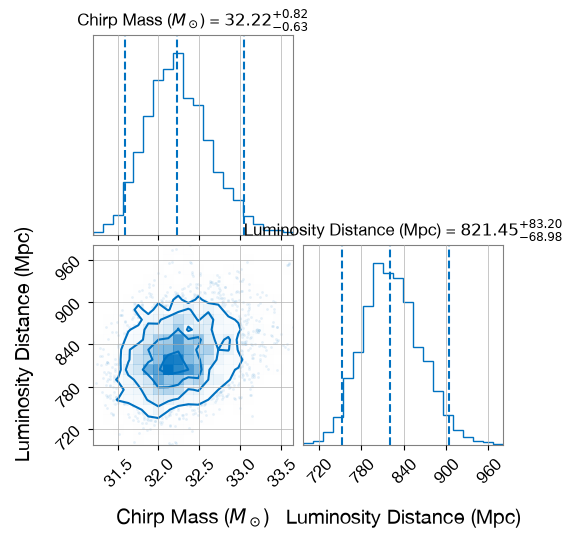

In [27]:
posterior = idata.posterior
mass_s = posterior["chirp_mass"].values.flatten()
dist_s = posterior["luminosity_distance"].values.flatten()
samples_2d = np.vstack([mass_s, dist_s]).T

fig = corner.corner(
    samples_2d,
    labels=[r"Chirp Mass ($M_\odot$)", r"Luminosity Distance (Mpc)"],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    quantiles=[0.03, 0.5, 0.97],
    color="#0072C1",
)
plt.show()

## 6. Trace Plot

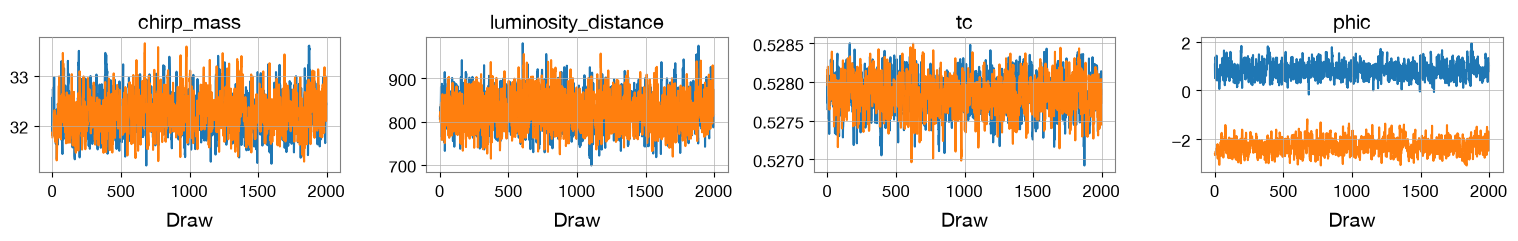

In [28]:
az.plot_trace(idata, var_names=["chirp_mass", "luminosity_distance", "tc", "phic"],
              backend="matplotlib")
plt.tight_layout()
plt.show()


## 7. Performance Notes

| Metric | NUTS (this pipeline) | Traditional Nested Sampling (Bilby/Dynesty) |
|---|---|---|
| Wall-clock (GW150914) | ~4 min | ~36 hours (est.) |
| ESS / sec | ~3.4 | ~0.01-0.02 |
| Gradient-based | Yes (JAX autodiff) | No |

**Reference:** Abbott et al. (2016) Phys.Rev.Lett. 116, 061102
**Code:** `gw_analytics` package in this repository.